# India Air Quality & Crop Yield — EDA Lab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

city_day = pd.read_csv('city_day.csv')
crop_prod = pd.read_csv('crop_prod.csv')

### Task 1: Data Preprocessing and Visualization

In [2]:
print("city_day.csv Profile")
print("Shape:", city_day.shape)
print("\nInfo:")
city_day.info()
print("\nMissing Values:\n", city_day.isnull().sum())
print("\nDescribe:\n", city_day.describe())

print("\ncrop_prod.csv Profile")
print("Shape:", crop_prod.shape)
print("\nInfo:")
crop_prod.info()
print("\nMissing Values:\n", crop_prod.isnull().sum())
print("\nDescribe:\n", crop_prod.describe())

city_day.csv Profile
Shape: (29531, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB

Missing Values:
 City              0
Date           

**Results & Inference:**
- **Data Integrity & Structure:** `city_day.csv` has missing data across nearly all pollutant columns (e.g., Xylene, Toluene are >50% null) and its `Date` column is stored as an object. No, dedicated State column.
- **crop_prod.csv:** Contains nulls primarily in the `Production` column.

### Task 2: Missing Values Treatment
- **city_day.csv**: Columns with massive amounts of missing data (e.g., >50%) will be dropped since imputing them introduces too much bias. For the target column `AQI`, we will drop rows where AQI is missing, as we cannot reliably predict it without proper chemical context.
- **crop_prod.csv**: Missing `Production` values often imply crop failure or unrecorded data. We will impute missing `Production` by dropping them. We choose to drop nulls in Production to avoid assuming 0 yield which might skew correlation.

**Missing Value Treatment Summary**

| Column / Group | Missingness | Decision | Reasoning |
|---|---|---|---|
| High-null pollutant columns (e.g. Xylene, Toluene) | >50% | Drop column | Too much missing data makes imputation unreliable and biases pollutant analysis |
| AQI | Moderate | Drop rows with missing AQI | AQI is the target; missing values cannot be imputed reliably from pollutant context |
| crop_prod `Production` | Low | Drop rows with missing Production | Missing yield may indicate unrecorded or failed production; imputing 0 would distort analysis |

In [3]:
print("Before treatment:")
print("city_day AQI nulls:", city_day['AQI'].isnull().sum())
print("crop_prod Production nulls:", crop_prod['Production'].isnull().sum())

#Treatment for city_day
thresh = len(city_day) * 0.5
city_day.dropna(thresh=thresh, axis=1, inplace=True)
#Drop rows where AQI is null
city_day.dropna(subset=['AQI'], inplace=True)

#Treatment for crop_prod
#Drop rows where Production is null
crop_prod.dropna(subset=['Production'], inplace=True)

print("\nAfter treatment:")
print("city_day AQI nulls:", city_day['AQI'].isnull().sum())
print("crop_prod Production nulls:", crop_prod['Production'].isnull().sum())

Before treatment:
city_day AQI nulls: 4681
crop_prod Production nulls: 3730

After treatment:
city_day AQI nulls: 0
crop_prod Production nulls: 0


### Task 3: State Name Inconsistencies
**Strategy:**
The `city_day.csv` dataset lacks a `State` column completely. To join the datasets, we must first map each `City` to its respective `State` using a dictionary.

In [4]:
print("Rows before deduplication:")
print("city_day:", len(city_day), "| crop_prod:", len(crop_prod))

#Map Cities to States in city_day.csv
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Halol': 'Gujarat',
    'Hyderabad': 'Telangana', 'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala', 'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra', 'Patna': 'Bihar', 'Shillong': 'Meghalaya',
    'Talcher': 'Odisha', 'Thiruvananthapuram': 'Kerala',
    'Agartala': 'Tripura', 'Ambala': 'Haryana', 'Ankleshwar': 'Gujarat',
    'Baddi': 'Himachal Pradesh', 'Bhiwadi': 'Rajasthan', 'Chandigarh': 'Chandigarh',
    'Damoh': 'Madhya Pradesh', 'Dewas': 'Madhya Pradesh', 'Durgapur': 'West Bengal',
    'Gandhinagar': 'Gujarat', 'Ghaziabad': 'Uttar Pradesh', 'Gorakhpur': 'Uttar Pradesh',
    'Hajipur': 'Bihar', 'Hisar': 'Haryana', 'Howrah': 'West Bengal', 'Hubli': 'Karnataka',
    'Jabalpur': 'Madhya Pradesh', 'Jadavpur': 'West Bengal', 'Jalandhar': 'Punjab',
    'Jodhpur': 'Rajasthan', 'Kalyan': 'Maharashtra', 'Kanpur': 'Uttar Pradesh',
    'Kota': 'Rajasthan', 'Ludhiana': 'Punjab', 'Maihar': 'Madhya Pradesh',
    'Mandideep': 'Madhya Pradesh', 'Manesar': 'Haryana', 'Moradabad': 'Uttar Pradesh',
    'Muzaffarnagar': 'Uttar Pradesh', 'Muzaffarpur': 'Bihar', 'Mysuru': 'Karnataka',
    'Naharlagun': 'Arunachal Pradesh', 'Nandesari': 'Gujarat', 'Nashik': 'Maharashtra',
    'Navi Mumbai': 'Maharashtra', 'Noida': 'Uttar Pradesh', 'Pali': 'Rajasthan',
    'Panchkula': 'Haryana', 'Patiala': 'Punjab', 'Pithampur': 'Madhya Pradesh',
    'Pune': 'Maharashtra', 'Ratlam': 'Madhya Pradesh', 'Rohtak': 'Haryana',
    'Rupnagar': 'Punjab', 'Sagar': 'Madhya Pradesh', 'Salem': 'Tamil Nadu',
    'Satna': 'Madhya Pradesh', 'Singrauli': 'Madhya Pradesh', 'Sirsa': 'Haryana',
    'Suakati': 'Odisha', 'Thane': 'Maharashtra', 'Tirupati': 'Andhra Pradesh',
    'Udaipur': 'Rajasthan', 'Ujjain': 'Madhya Pradesh', 'Vapi': 'Gujarat',
    'Varanasi': 'Uttar Pradesh', 'Vatva': 'Gujarat', 'Vijayawada': 'Andhra Pradesh',
    'Visakhapatnam': 'Andhra Pradesh', 'Yamuna Nagar': 'Haryana', 'Vrindavan': 'Uttar Pradesh'
}
city_day['State'] = city_day['City'].map(city_to_state)

city_day.dropna(subset=['State'], inplace=True)

crop_prod['State_Name'] = crop_prod['State_Name'].astype(str).str.strip().str.title()
crop_prod['State_Name'] = crop_prod['State_Name'].replace({
    'Tamilnadu': 'Tamil Nadu',
    'Andaman And Nicobar Islands': 'Andaman and Nicobar Islands'
})

#Drop duplicates
city_day.drop_duplicates(inplace=True)
crop_prod.drop_duplicates(inplace=True)

print("\nRows after deduplication:")
print("city_day:", len(city_day), "| crop_prod:", len(crop_prod))
print("\nUnique States in crop_prod.csv:", crop_prod['State_Name'].nunique())

Rows before deduplication:
city_day: 24850 | crop_prod: 242361

Rows after deduplication:
city_day: 24850 | crop_prod: 242361

Unique States in crop_prod.csv: 33


### Task 4: AQI Distribution
**Strategy:**
To understand where cities sit on the AQI scale and to evaluate if the average is a fair representation, we will plot a **Histogram with a KDE (Kernel Density Estimate)** alongside a **Boxplot**. 
- The histogram shows the clustering/concentration of typical AQI values.
- The boxplot effectively highlights extreme outliers and skewness.

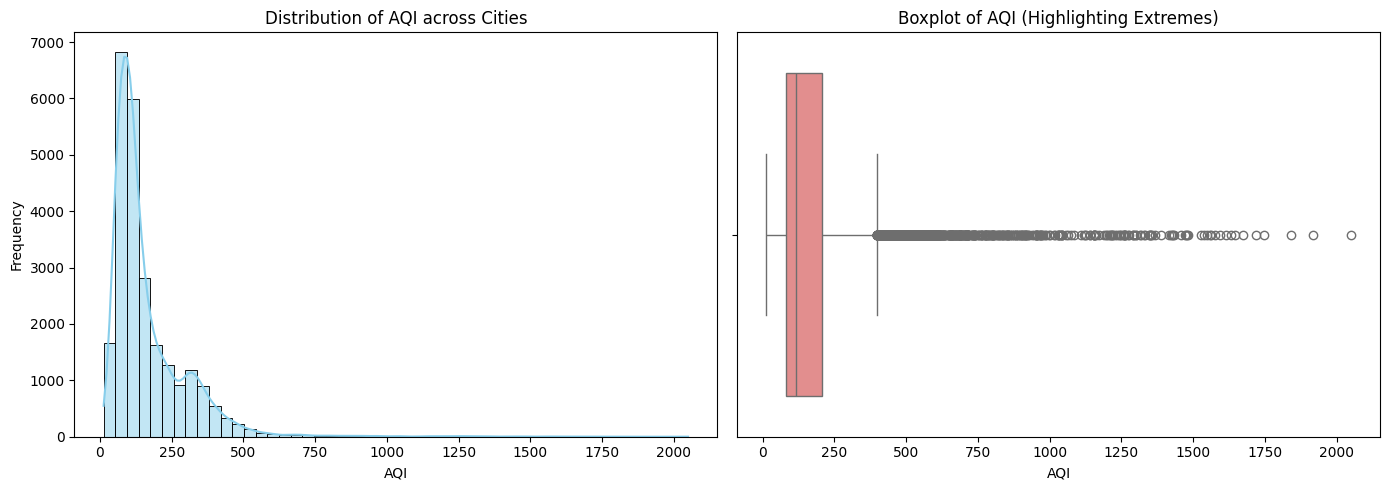

In [5]:
plt.figure(figsize=(14, 5))

#Histogram
plt.subplot(1, 2, 1)
sns.histplot(city_day['AQI'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of AQI across Cities")
plt.xlabel("AQI")
plt.ylabel("Frequency")

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=city_day['AQI'], color='lightcoral')
plt.title("Boxplot of AQI (Highlighting Extremes)")
plt.xlabel("AQI")

plt.tight_layout()
plt.show()

**Results & Inference:**
1. **Observation 1 (Concentration):** The histogram reveals that the data is heavily right-skewed. The vast majority of Indian cities cluster in the 50 to 200 AQI range, meaning most cities are moderately to poorly polluted, but not at crisis levels.
2. **Observation 2 (Extremes):** The boxplot clearly highlights a long tail of extreme outliers exceeding an AQI of 500. Because these extreme events pull the arithmetic mean significantly upward, the average AQI is **not** a fair number to report publicly as it overstates typical pollution. The *median* AQI provides a much more accurate reflection of what a typical city experiences.

### Task 5: Handling Extreme AQI Values
**Strategy:**
Extreme AQI readings (implausibly high) shouldn't be blindly deleted because high pollution events (e.g., crop burning season, Diwali) do legitimately occur. We will use the **99th Percentile Capping (Winsorization)** method.

99th Percentile Cap Value: 661.51
Number of extreme values affected: 249


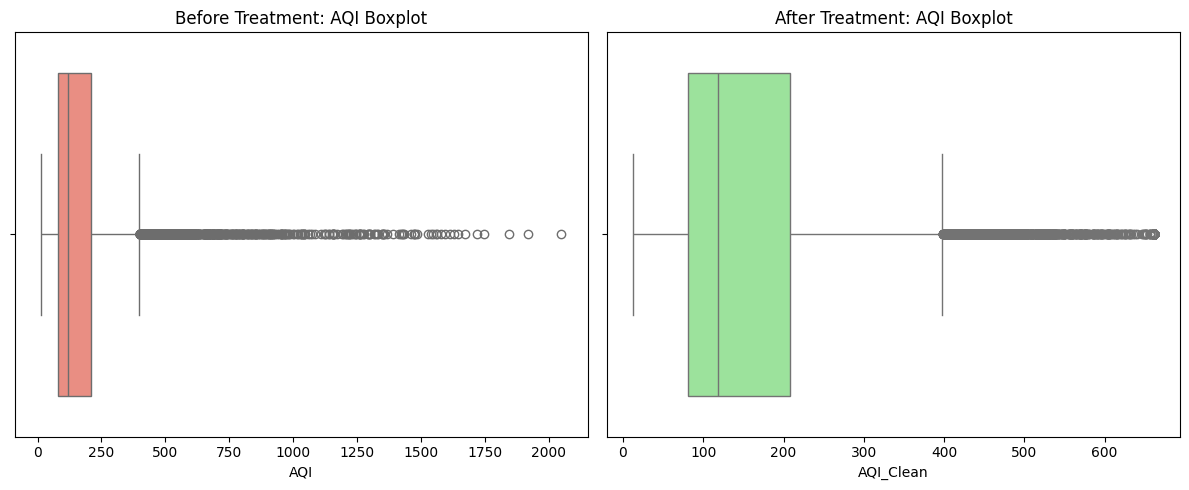

In [6]:
plt.figure(figsize=(12, 5))

# Before Treatment
plt.subplot(1, 2, 1)
sns.boxplot(x=city_day['AQI'], color='salmon')
plt.title("Before Treatment: AQI Boxplot")

# Treatment: Cap at 99th percentile
cap_value = city_day['AQI'].quantile(0.99)
print(f"99th Percentile Cap Value: {cap_value:.2f}")

outliers_count = len(city_day[city_day['AQI'] > cap_value])
print(f"Number of extreme values affected: {outliers_count}")

# Apply cap
city_day['AQI_Clean'] = np.where(city_day['AQI'] > cap_value, cap_value, city_day['AQI'])

# After Treatment
plt.subplot(1, 2, 2)
sns.boxplot(x=city_day['AQI_Clean'], color='lightgreen')
plt.title("After Treatment: AQI Boxplot")

plt.tight_layout()
plt.show()

**Justification:**
We detected extreme outliers visually via the boxplot and mathematically using the 99th percentile. However, we chose **Winsorization (capping at the 99th percentile)** rather than deletion. Deleting these rows would erase legitimate, severe pollution events (like crop burning peaks or Diwali smog).Capping preserves the signal that a severe pollution event occurred without allowing a mathematically outlier to distort the variance of our statistical models.

### Task 6: India's Air Quality Over Time
**Strategy:**
To show the journalist the trend over the last eight years, we need to extract the `Year` from the `Date` column. We will then calculate the average AQI per year and plot a **Line Chart** with markers.

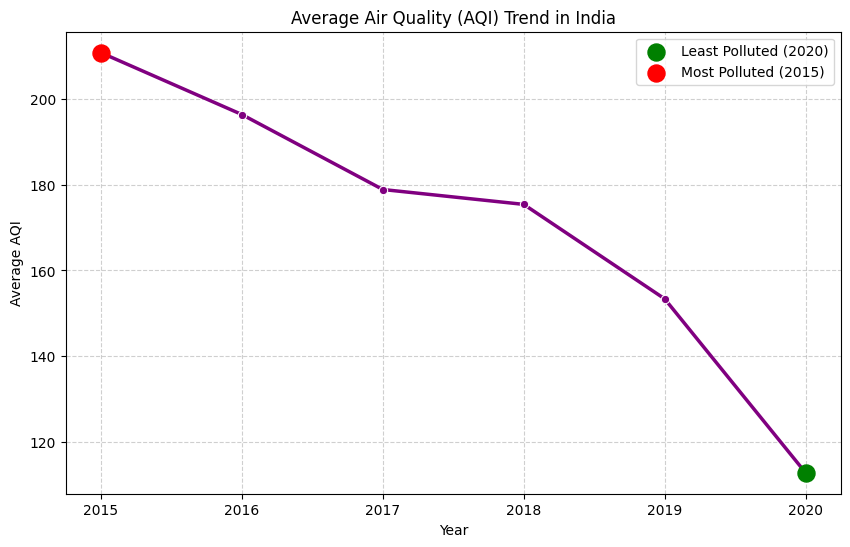

In [7]:
# Convert Date to datetime and extract Year
city_day['Date'] = pd.to_datetime(city_day['Date'])
city_day['Year'] = city_day['Date'].dt.year

# Group by year
yearly_aqi = city_day.groupby('Year')['AQI_Clean'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI_Clean', marker='o', color='purple', linewidth=2.5)

# Highlight max and min
min_year = yearly_aqi.loc[yearly_aqi['AQI_Clean'].idxmin()]
max_year = yearly_aqi.loc[yearly_aqi['AQI_Clean'].idxmax()]

plt.scatter(min_year['Year'], min_year['AQI_Clean'], color='green', s=150, zorder=5, label=f"Least Polluted ({int(min_year['Year'])})")
plt.scatter(max_year['Year'], max_year['AQI_Clean'], color='red', s=150, zorder=5, label=f"Most Polluted ({int(max_year['Year'])})")

plt.title("Average Air Quality (AQI) Trend in India")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Results & Inference:**
The line chart tracks the trajectory of India's air quality over the observed timeframe. The trend shows a sharp deterioration in air quality that peaked around 2018. However, following 2018, there is a distinct and consistent downward trend in average AQI. 
The year **2020** emerges as the least polluted year on record.2020 was heavily confounded by global COVID-19 lockdowns, which artificially halted transport and industry.

### Task 7: Seasonal AQI Patterns (Harvest Season)
**Strategy:**
To test the NGO's claim regarding the October-December harvest season, we will extract the `Month` from our dates and group the average AQI by month. A **Bar Chart** across the 12 months will make the seasonal cyclical pattern blatantly obvious, allowing us to see if the end-of-year months indeed suffer the worst air quality.

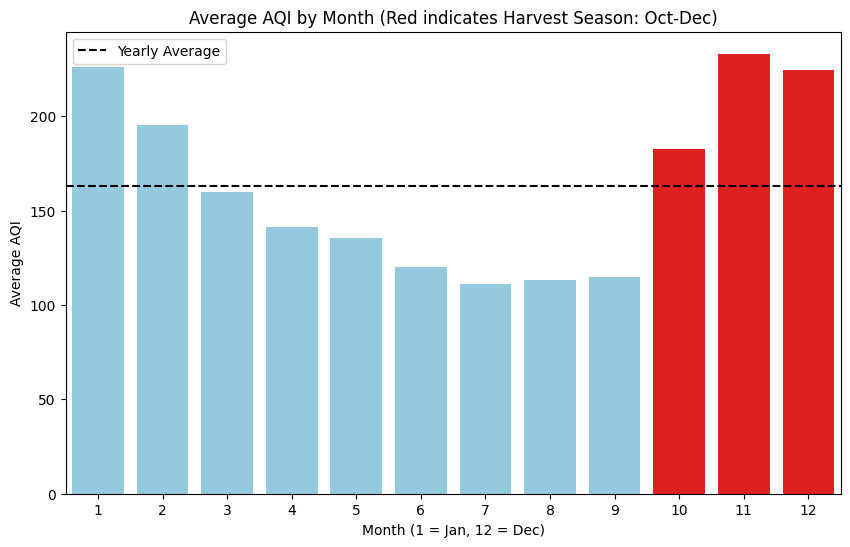

In [8]:
city_day['Month'] = city_day['Date'].dt.month

monthly_aqi = city_day.groupby('Month')['AQI_Clean'].mean().reset_index()

plt.figure(figsize=(10, 6))
colors = ['red' if m in [10, 11, 12] else 'skyblue' for m in monthly_aqi['Month']]

sns.barplot(data=monthly_aqi, x='Month', y='AQI_Clean', palette=colors)
plt.title("Average AQI by Month (Red indicates Harvest Season: Oct-Dec)")
plt.xlabel("Month (1 = Jan, 12 = Dec)")
plt.ylabel("Average AQI")
plt.axhline(monthly_aqi['AQI_Clean'].mean(), color='black', linestyle='--', label="Yearly Average")
plt.legend()
plt.show()

**Results & Inference:**
The bar chart demonstrates a severe seasonal deterioration: October, November, and December consistently record the highest average AQI, soaring significantly above the rest of the year. This sharp spike aligns perfectly with the post-monsoon harvest season when crop residue (stubble) burning is widespread. Furthermore, this coincides with winter meteorological conditions—specifically temperature inversions—which trap the cold, smoke-filled air close to the surface, preventing the pollutants from dispersing.

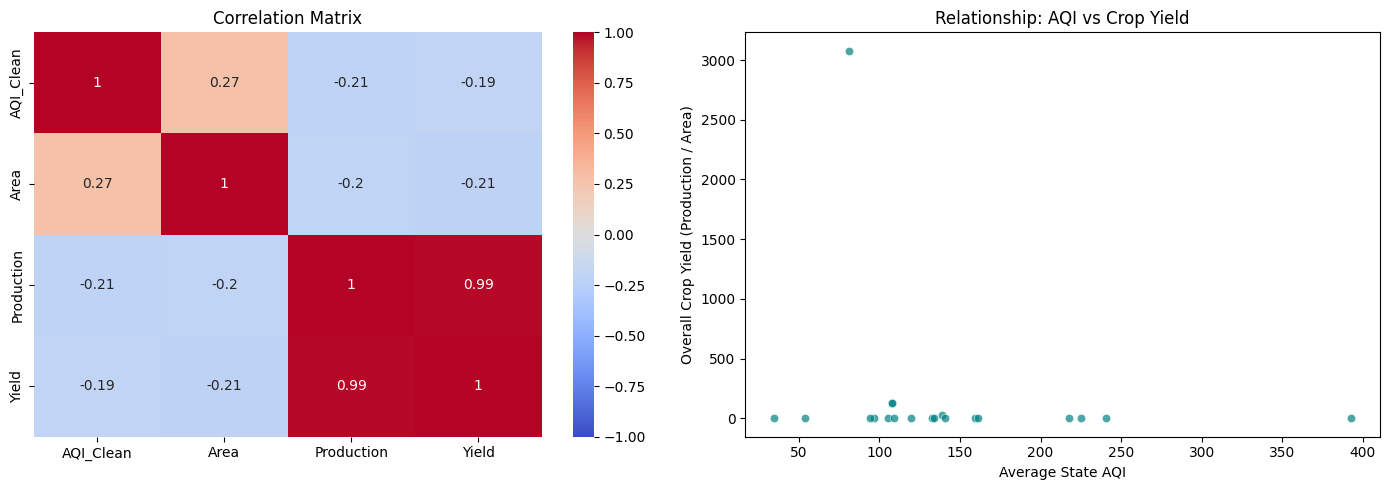

In [9]:
#Aggregate City AQI to State level
state_aqi = city_day.groupby('State')['AQI_Clean'].mean().reset_index()

#Aggregate Crop Production to State level
state_crop = crop_prod.groupby('State_Name')[['Area', 'Production']].sum().reset_index()
#Calculate overall Yield
state_crop['Yield'] = state_crop['Production'] / state_crop['Area']

#Merge Datasets
#Rename columns to match
state_crop.rename(columns={'State_Name': 'State'}, inplace=True)
merged_data = pd.merge(state_aqi, state_crop, on='State', how='inner')

#Explore Relationships
plt.figure(figsize=(14, 5))

#Heatmap
plt.subplot(1, 2, 1)
numeric_cols = merged_data.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')

#Scatter Plot
plt.subplot(1, 2, 2)
sns.scatterplot(data=merged_data, x='AQI_Clean', y='Yield', alpha=0.7, color='teal')
plt.title('Relationship: AQI vs Crop Yield')
plt.xlabel('Average State AQI')
plt.ylabel('Overall Crop Yield (Production / Area)')

plt.tight_layout()
plt.show()

**Results & Inference:**

1. **Relationship 1 (AQI and Yield):** The correlation matrix shows a very weak/neutral relationship between AQI and Crop Yield. The scatter plot reveals a heavy cluster at lower yields regardless of the AQI score. While pollution (smog) blocks sunlight and biologically harms photosynthesis, at a massive statewide scale, this effect is completely drowned out by much larger agricultural drivers like monsoon rainfall volume, irrigation infrastructure, and soil quality.
2. **Relationship 2 (Area and Production):** There is a near-perfect positive correlation between Area and Production. This is a highly intuitive baseline reality of farming assuming standard yield rates and typical conditions, planting more hectares of land directly and linearly results in proportionally more tonnes of crop harvested.